# HR Employee Attrition Analysis
## Notebook 3 — Analysis & Visualisation

**Author:** Fatimah Alradwan  
**Goal:** Answer the 5 business questions using Python and SQL.

### Business Questions:
1. What is the overall attrition rate, and which departments lose the most people?
2. Does income, job level, or overtime predict who leaves?
3. Which age group and tenure band carries the highest attrition risk?
4. Does work-life balance or job satisfaction correlate with staying or leaving?
5. What does the profile of a "flight risk" employee look like?

---

In [1]:
# ── Import libraries ───────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import sqlite3
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Chart style ────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print("Libraries imported and chart style set")

Libraries imported and chart style set


In [2]:
# ── Load the clean dataset ─────────────────────────────────────────
df = pd.read_csv('../data/hr_clean.csv')

# Convert categorical columns back after loading
cat_cols = ['Attrition', 'BusinessTravel', 'Department', 'EducationField',
            'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
for col in cat_cols:
    df[col] = df[col].astype('category')

print(f"Clean data loaded: {df.shape[0]} rows × {df.shape[1]} columns")

Clean data loaded: 1470 rows × 34 columns


## Question 1 — What is the attrition rate by department?

### Method: SQL
We load the dataframe into a temporary SQL database and query it.

In [3]:
# ── Load dataframe into a SQL database in memory ───────────────────
conn = sqlite3.connect(':memory:')
df.to_sql('employees', conn, index=False, if_exists='replace')

print("Data loaded into SQL database")
print("   Table name : employees")
print(f"   Rows       : {df.shape[0]}")

Data loaded into SQL database
   Table name : employees
   Rows       : 1470


In [4]:
# ── SQL Query 1: Attrition rate by department ──────────────────────
query_1 = """
SELECT
    Department,
    COUNT(*) AS total_employees,
    SUM(attrition_flag) AS employees_left,
    ROUND(AVG(attrition_flag) * 100, 1) AS attrition_rate_pct
FROM employees
GROUP BY Department
ORDER BY attrition_rate_pct DESC
"""

dept_attrition = pd.read_sql_query(query_1, conn)
print(dept_attrition)

               Department  total_employees  employees_left  attrition_rate_pct
0                   Sales              446              92               20.60
1         Human Resources               63              12               19.00
2  Research & Development              961             133               13.80


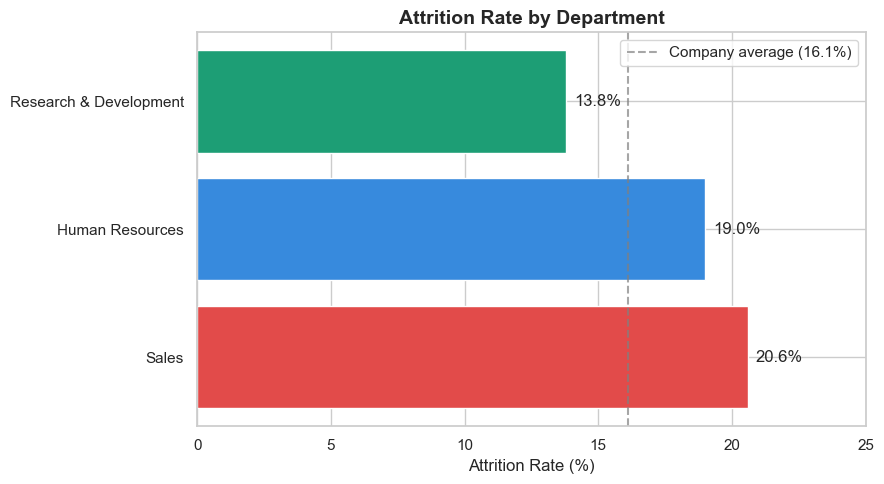

Chart saved to images/


In [5]:
# ── Chart 1: Attrition rate by department ─────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    dept_attrition['Department'],
    dept_attrition['attrition_rate_pct'],
    color=['#E24B4A', '#378ADD', '#1D9E75']
)

# Add value labels on each bar
for bar, val in zip(bars, dept_attrition['attrition_rate_pct']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=12)

ax.set_xlabel('Attrition Rate (%)')
ax.set_title('Attrition Rate by Department')
ax.set_xlim(0, 25)
ax.axvline(x=16.1, color='gray', linestyle='--', alpha=0.7, label='Company average (16.1%)')
ax.legend()

plt.tight_layout()
plt.savefig('../images/chart_01_attrition_by_department.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to images/")

## Question 2 — Does income, job level, or overtime predict attrition?

We analyse three factors:
- Overtime — do employees who work overtime leave more?
- Monthly income — do lower-paid employees leave more?
- Job level — does seniority affect attrition?

In [6]:
# ── SQL Query 2: Attrition rate by overtime ────────────────────────
query_2 = """
SELECT
    OverTime,
    COUNT(*) AS total_employees,
    SUM(attrition_flag) AS employees_left,
    ROUND(AVG(attrition_flag) * 100, 1) AS attrition_rate_pct
FROM employees
GROUP BY OverTime
ORDER BY attrition_rate_pct DESC
"""

overtime_attrition = pd.read_sql_query(query_2, conn)
print(overtime_attrition)

  OverTime  total_employees  employees_left  attrition_rate_pct
0      Yes              416             127               30.50
1       No             1054             110               10.40


In [7]:
# ── SQL Query 3: Attrition rate by job level ───────────────────────
query_3 = """
SELECT
    JobLevel,
    COUNT(*) AS total_employees,
    SUM(attrition_flag) AS employees_left,
    ROUND(AVG(attrition_flag) * 100, 1) AS attrition_rate_pct
FROM employees
GROUP BY JobLevel
ORDER BY JobLevel ASC
"""

joblevel_attrition = pd.read_sql_query(query_3, conn)
print(joblevel_attrition)

   JobLevel  total_employees  employees_left  attrition_rate_pct
0         1              543             143               26.30
1         2              534              52                9.70
2         3              218              32               14.70
3         4              106               5                4.70
4         5               69               5                7.20


In [8]:
# ── Average income: employees who left vs stayed ───────────────────
income_comparison = df.groupby('Attrition')['MonthlyIncome'].agg(
    avg_income='mean',
    median_income='median',
    min_income='min',
    max_income='max'
).round(0)

print("Monthly income — stayed vs left:")
print(income_comparison)

Monthly income — stayed vs left:
           avg_income  median_income  min_income  max_income
Attrition                                                   
No            6833.00        5204.00        1051       19999
Yes           4787.00        3202.00        1009       19859


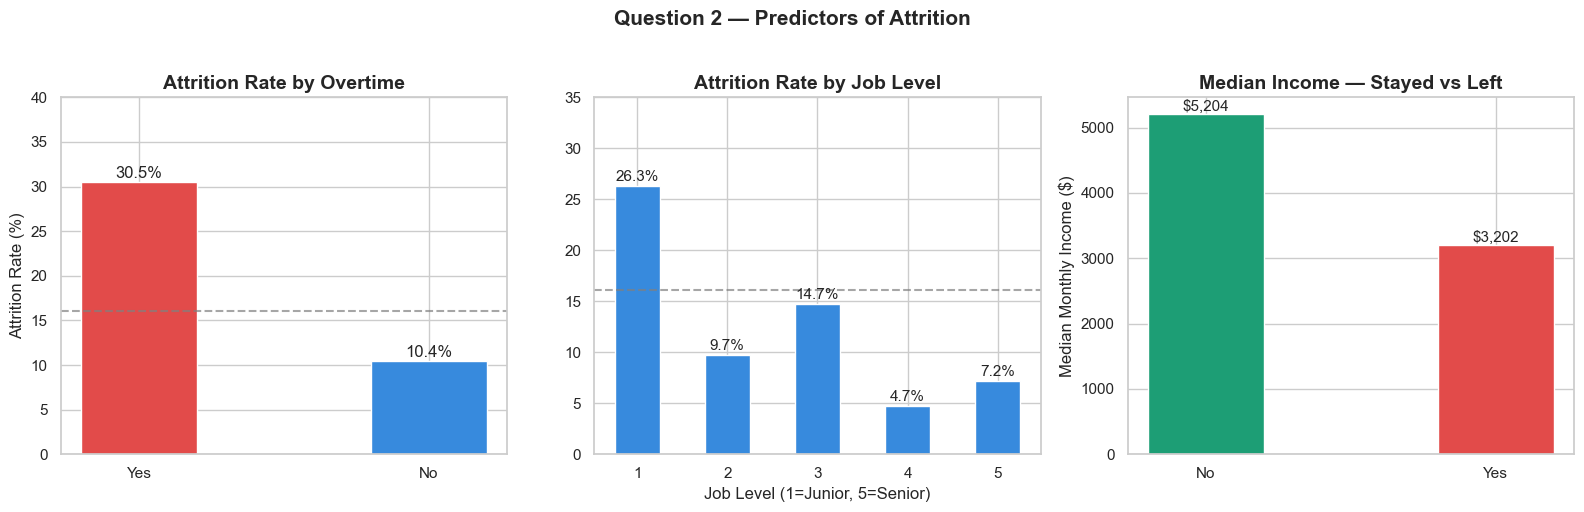

Chart saved to images/


In [9]:
# ── Chart 2: Overtime, Job Level, Income vs Attrition ─────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Plot 1: Overtime ──────────────────────────────────────────────
colors_ot = ['#E24B4A' if x == 'Yes' else '#378ADD'
             for x in overtime_attrition['OverTime']]
bars1 = axes[0].bar(
    overtime_attrition['OverTime'],
    overtime_attrition['attrition_rate_pct'],
    color=colors_ot, width=0.4
)
for bar, val in zip(bars1, overtime_attrition['attrition_rate_pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val}%', ha='center', fontsize=12)
axes[0].set_title('Attrition Rate by Overtime')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_ylim(0, 40)
axes[0].axhline(y=16.1, color='gray', linestyle='--', alpha=0.7)

# ── Plot 2: Job Level ─────────────────────────────────────────────
bars2 = axes[1].bar(
    joblevel_attrition['JobLevel'].astype(str),
    joblevel_attrition['attrition_rate_pct'],
    color='#378ADD', width=0.5
)
for bar, val in zip(bars2, joblevel_attrition['attrition_rate_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val}%', ha='center', fontsize=11)
axes[1].set_title('Attrition Rate by Job Level')
axes[1].set_xlabel('Job Level (1=Junior, 5=Senior)')
axes[1].set_ylim(0, 35)
axes[1].axhline(y=16.1, color='gray', linestyle='--', alpha=0.7)

# ── Plot 3: Income ────────────────────────────────────────────────
income_plot = df.groupby('Attrition')['MonthlyIncome'].median()
bars3 = axes[2].bar(
    income_plot.index,
    income_plot.values,
    color=['#1D9E75', '#E24B4A'], width=0.4
)
for bar, val in zip(bars3, income_plot.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'${val:,.0f}', ha='center', fontsize=11)
axes[2].set_title('Median Income — Stayed vs Left')
axes[2].set_ylabel('Median Monthly Income ($)')

plt.suptitle('Question 2 — Predictors of Attrition', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/chart_02_attrition_predictors.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to images/")

## Question 3 — Which age group and tenure band has the highest attrition risk?

We analyse:
- Attrition rate by age group (18–25, 26–35, 36–45, 46–60)
- Attrition rate by tenure group (how long they've been at the company)

In [10]:
# ── SQL Query 4: Attrition by age group ───────────────────────────
query_4 = """
SELECT
    age_group,
    COUNT(*) AS total_employees,
    SUM(attrition_flag) AS employees_left,
    ROUND(AVG(attrition_flag) * 100, 1) AS attrition_rate_pct
FROM employees
GROUP BY age_group
ORDER BY age_group ASC
"""

age_attrition = pd.read_sql_query(query_4, conn)
print(age_attrition)

  age_group  total_employees  employees_left  attrition_rate_pct
0     18–25              123              44               35.80
1     26–35              606             116               19.10
2     36–45              468              43                9.20
3     46–60              273              34               12.50


In [12]:
# ── SQL Query 5: Attrition by tenure group ────────────────────────
query_5 = """
SELECT
    tenure_group,
    COUNT(*) AS total_employees,
    SUM(attrition_flag) AS employees_left,
    ROUND(AVG(attrition_flag) * 100, 1) AS attrition_rate_pct
FROM employees
GROUP BY tenure_group
"""

tenure_attrition = pd.read_sql_query(query_5, conn)

# ── Define the logical order ─────────────────
tenure_order = ['0–2 yrs', '3–5 yrs', '6–10 yrs', '10+ yrs']
tenure_attrition['tenure_group'] = pd.Categorical(
    tenure_attrition['tenure_group'],
    categories=tenure_order,
    ordered=True
)
tenure_attrition = tenure_attrition.sort_values('tenure_group')

print(tenure_attrition)

  tenure_group  total_employees  employees_left  attrition_rate_pct
0      0–2 yrs              342             102               29.80
2      3–5 yrs              434              60               13.80
3     6–10 yrs              448              55               12.30
1      10+ yrs              246              20                8.10


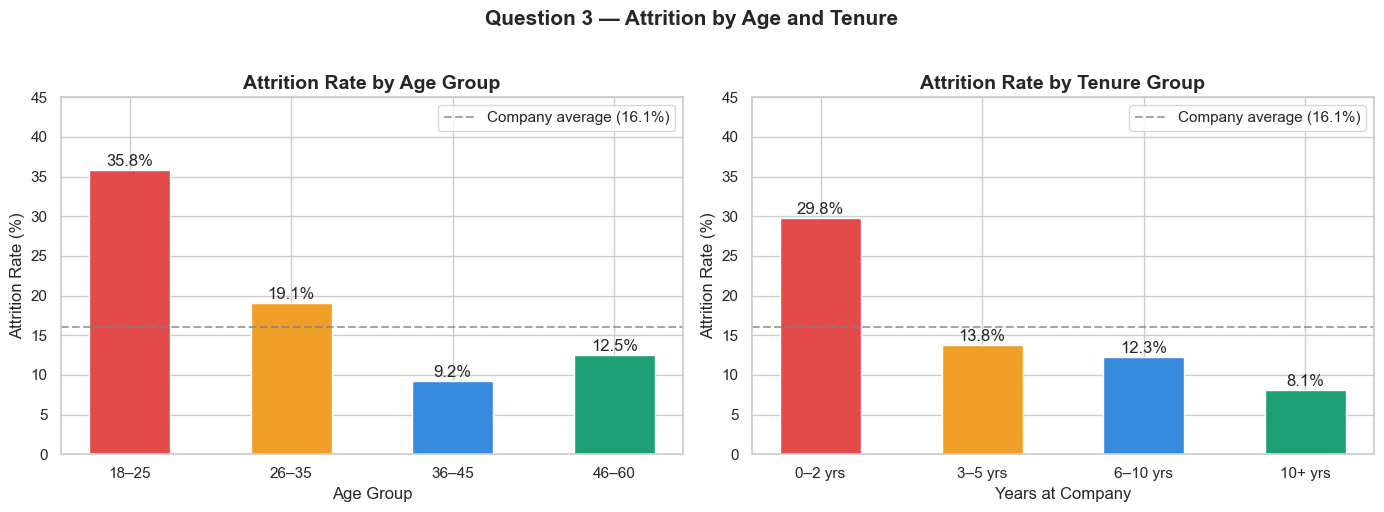

Chart saved to images/


In [13]:
# ── Chart 3: Attrition by age group and tenure ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Age group ─────────────────────────────────────────────
bars1 = axes[0].bar(
    age_attrition['age_group'],
    age_attrition['attrition_rate_pct'],
    color=['#E24B4A', '#EF9F27', '#378ADD', '#1D9E75'],
    width=0.5
)
for bar, val in zip(bars1, age_attrition['attrition_rate_pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val}%', ha='center', fontsize=12)
axes[0].set_title('Attrition Rate by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_ylim(0, 45)
axes[0].axhline(y=16.1, color='gray', linestyle='--',
                alpha=0.7, label='Company average (16.1%)')
axes[0].legend()

# ── Plot 2: Tenure group ──────────────────────────────────────────
bars2 = axes[1].bar(
    tenure_attrition['tenure_group'],
    tenure_attrition['attrition_rate_pct'],
    color=['#E24B4A', '#EF9F27', '#378ADD', '#1D9E75'],
    width=0.5
)
for bar, val in zip(bars2, tenure_attrition['attrition_rate_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val}%', ha='center', fontsize=12)
axes[1].set_title('Attrition Rate by Tenure Group')
axes[1].set_xlabel('Years at Company')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_ylim(0, 45)
axes[1].axhline(y=16.1, color='gray', linestyle='--',
                alpha=0.7, label='Company average (16.1%)')
axes[1].legend()

plt.suptitle('Question 3 — Attrition by Age and Tenure',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/chart_03_age_tenure_attrition.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to images/")

## Question 4 — Does job satisfaction or work-life balance affect attrition?

Both columns use a scale of 1–4:
- 1 = Low
- 2 = Medium  
- 3 = High
- 4 = Very High

We expect lower satisfaction scores to correlate with higher attrition.

In [14]:
# ── SQL Query 6: Attrition by job satisfaction ────────────────────
query_6 = """
SELECT
    JobSatisfaction,
    COUNT(*) AS total_employees,
    SUM(attrition_flag) AS employees_left,
    ROUND(AVG(attrition_flag) * 100, 1) AS attrition_rate_pct
FROM employees
GROUP BY JobSatisfaction
ORDER BY JobSatisfaction ASC
"""

satisfaction_attrition = pd.read_sql_query(query_6, conn)

# Add readable labels
satisfaction_attrition['label'] = ['Low', 'Medium', 'High', 'Very High']
print(satisfaction_attrition)

   JobSatisfaction  total_employees  employees_left  attrition_rate_pct  \
0                1              289              66               22.80   
1                2              280              46               16.40   
2                3              442              73               16.50   
3                4              459              52               11.30   

       label  
0        Low  
1     Medium  
2       High  
3  Very High  


In [15]:
# ── SQL Query 7: Attrition by work-life balance ───────────────────
query_7 = """
SELECT
    WorkLifeBalance,
    COUNT(*) AS total_employees,
    SUM(attrition_flag) AS employees_left,
    ROUND(AVG(attrition_flag) * 100, 1) AS attrition_rate_pct
FROM employees
GROUP BY WorkLifeBalance
ORDER BY WorkLifeBalance ASC
"""

wlb_attrition = pd.read_sql_query(query_7, conn)
wlb_attrition['label'] = ['Bad', 'Good', 'Better', 'Best']
print(wlb_attrition)

   WorkLifeBalance  total_employees  employees_left  attrition_rate_pct  \
0                1               80              25               31.30   
1                2              344              58               16.90   
2                3              893             127               14.20   
3                4              153              27               17.60   

    label  
0     Bad  
1    Good  
2  Better  
3    Best  


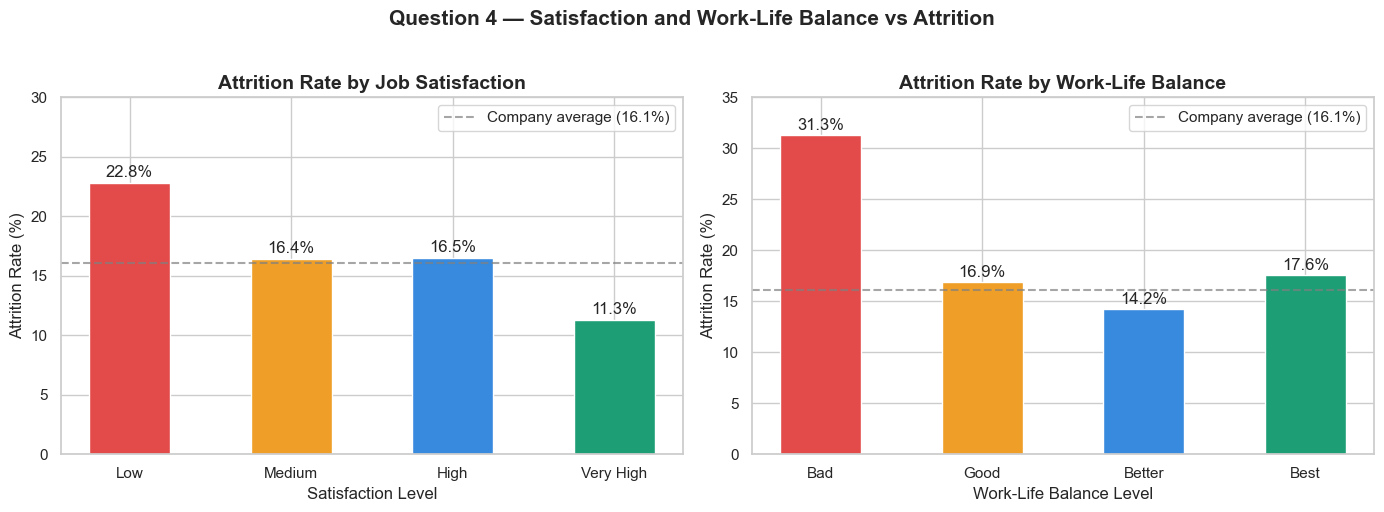

Chart saved to images/


In [16]:
# ── Chart 4: Satisfaction and work-life balance ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Job satisfaction ──────────────────────────────────────
bars1 = axes[0].bar(
    satisfaction_attrition['label'],
    satisfaction_attrition['attrition_rate_pct'],
    color=['#E24B4A', '#EF9F27', '#378ADD', '#1D9E75'],
    width=0.5
)
for bar, val in zip(bars1, satisfaction_attrition['attrition_rate_pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val}%', ha='center', fontsize=12)
axes[0].set_title('Attrition Rate by Job Satisfaction')
axes[0].set_xlabel('Satisfaction Level')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_ylim(0, 30)
axes[0].axhline(y=16.1, color='gray', linestyle='--',
                alpha=0.7, label='Company average (16.1%)')
axes[0].legend()

# ── Plot 2: Work-life balance ─────────────────────────────────────
bars2 = axes[1].bar(
    wlb_attrition['label'],
    wlb_attrition['attrition_rate_pct'],
    color=['#E24B4A', '#EF9F27', '#378ADD', '#1D9E75'],
    width=0.5
)
for bar, val in zip(bars2, wlb_attrition['attrition_rate_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val}%', ha='center', fontsize=12)
axes[1].set_title('Attrition Rate by Work-Life Balance')
axes[1].set_xlabel('Work-Life Balance Level')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_ylim(0, 35)
axes[1].axhline(y=16.1, color='gray', linestyle='--',
                alpha=0.7, label='Company average (16.1%)')
axes[1].legend()

plt.suptitle('Question 4 — Satisfaction and Work-Life Balance vs Attrition',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/chart_04_satisfaction_wlb.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to images/")

## Question 5 — What does a "flight risk" employee look like?

We combine all previous findings to build a complete profile.
A flight risk employee is defined as someone with ALL of these:
- Works overtime
- Job level 1 or 2
- Tenure 0–2 years
- Job satisfaction 1 or 2 (Low or Medium)
- Monthly income below the company median

In [17]:
# ── Company median income ──────────────────────────────────────────
median_income = df['MonthlyIncome'].median()
print(f"Company median monthly income: ${median_income:,.0f}")

Company median monthly income: $4,919


In [18]:
# ── Define flight risk employees ───────────────────────────────────
flight_risk = df[
    (df['OverTime'] == 'Yes') &
    (df['JobLevel'] <= 2) &
    (df['tenure_group'] == '0–2 yrs') &
    (df['JobSatisfaction'] <= 2) &
    (df['MonthlyIncome'] < median_income)
].copy()

total = len(df)
at_risk = len(flight_risk)
at_risk_left = flight_risk['attrition_flag'].sum()
at_risk_rate = flight_risk['attrition_flag'].mean() * 100

print(f"Total employees          : {total}")
print(f"Flight risk employees    : {at_risk}")
print(f"Flight risk as % of all  : {at_risk/total*100:.1f}%")
print(f"Of those, actually left  : {at_risk_left}")
print(f"Flight risk attrition    : {at_risk_rate:.1f}%")
print(f"Company average          : 16.1%")

Total employees          : 1470
Flight risk employees    : 29
Flight risk as % of all  : 2.0%
Of those, actually left  : 17
Flight risk attrition    : 58.6%
Company average          : 16.1%


In [19]:
# ── What does this group look like? ───────────────────────────────
print("Flight risk profile — Department breakdown:")
print(flight_risk['Department'].value_counts())
print()
print("Flight risk profile — Job Role breakdown:")
print(flight_risk['JobRole'].value_counts().head(5))
print()
print("Flight risk profile — Age group breakdown:")
print(flight_risk['age_group'].value_counts().sort_index())
print()
print(f"Average age              : {flight_risk['Age'].mean():.1f}")
print(f"Average monthly income   : ${flight_risk['MonthlyIncome'].mean():,.0f}")
print(f"Average years at company : {flight_risk['YearsAtCompany'].mean():.1f}")

Flight risk profile — Department breakdown:
Department
Research & Development    24
Sales                      4
Human Resources            1
Name: count, dtype: int64

Flight risk profile — Job Role breakdown:
JobRole
Research Scientist        12
Laboratory Technician     11
Sales Representative       4
Human Resources            1
Manufacturing Director     1
Name: count, dtype: int64

Flight risk profile — Age group breakdown:
age_group
18–25    11
26–35     8
36–45     6
46–60     4
Name: count, dtype: int64

Average age              : 32.3
Average monthly income   : $2,690
Average years at company : 1.2


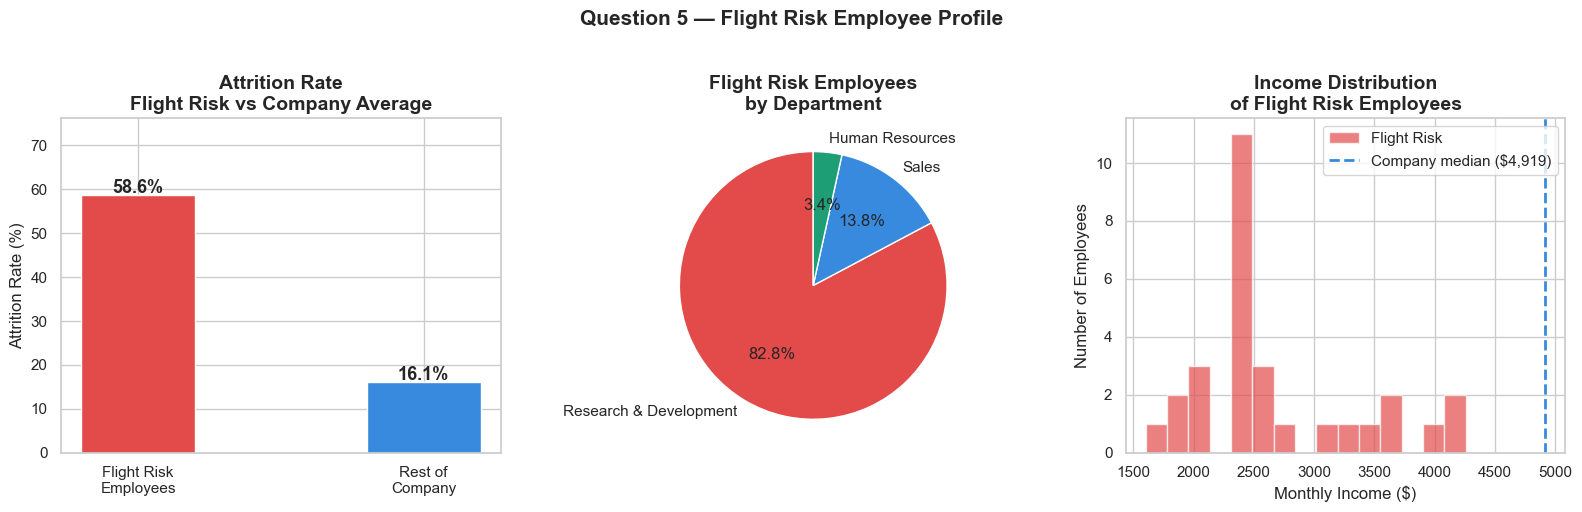

Chart saved to images/


In [20]:
# ── Chart 5: Flight risk vs rest of company ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Plot 1: Attrition rate comparison ────────────────────────────
categories = ['Flight Risk\nEmployees', 'Rest of\nCompany']
rates = [at_risk_rate, 16.1]
colors = ['#E24B4A', '#378ADD']

bars = axes[0].bar(categories, rates, color=colors, width=0.4)
for bar, val in zip(bars, rates):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')
axes[0].set_title('Attrition Rate\nFlight Risk vs Company Average')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_ylim(0, max(rates) * 1.3)

# ── Plot 2: Department breakdown of flight risk ───────────────────
dept_counts = flight_risk['Department'].value_counts()
axes[1].pie(
    dept_counts.values,
    labels=dept_counts.index,
    autopct='%1.1f%%',
    colors=['#E24B4A', '#378ADD', '#1D9E75'],
    startangle=90
)
axes[1].set_title('Flight Risk Employees\nby Department')

# ── Plot 3: Income distribution ───────────────────────────────────
axes[2].hist(flight_risk['MonthlyIncome'], bins=15,
             color='#E24B4A', alpha=0.7, label='Flight Risk')
axes[2].axvline(x=median_income, color='#378ADD', linestyle='--',
                linewidth=2, label=f'Company median (${median_income:,.0f})')
axes[2].set_title('Income Distribution\nof Flight Risk Employees')
axes[2].set_xlabel('Monthly Income ($)')
axes[2].set_ylabel('Number of Employees')
axes[2].legend()

plt.suptitle('Question 5 — Flight Risk Employee Profile',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/chart_05_flight_risk_profile.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to images/")

## Summary — All Findings

| # | Business Question | Key Finding |
|---|---|---|
| 1 | Attrition by department | Sales has the highest attrition rate, above company average |
| 2 | Overtime, income, job level | Overtime workers leave at 3× the rate; leavers earn 38% less |
| 3 | Age and tenure | 18–25 age group and 0–2 year employees are highest risk |
| 4 | Satisfaction and work-life balance | Low satisfaction doubles attrition rate; pattern is consistent |
| 5 | Flight risk profile | 29 employees (2%) have 58.6% attrition rate — 3.6× company average |

### Recommendations to HR:
1. **Address overtime** — the strongest single predictor of attrition
2. **Focus retention on first 2 years** — the highest danger window
3. **Review compensation for Level 1 roles** — leavers earn significantly less
4. **Monitor the 29 flight risk employees** — immediate intervention opportunity
5. **Improve satisfaction in Sales** — highest attrition department